# Checkeo de transformación canónica
Comprobamos si las expresiones derivadas para $H_1$ tras hacer las transformaciones sobre $H_0$ son correctas 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.special import genlaguerre, gammaln
import itertools
import scienceplots
plt.style.use(['science', 'notebook'])

In [2]:
def ssh_energies(band, omega_q, nu, w, U, k):
    delta = np.sqrt(nu**2 + w**2 + 2 * nu * w * np.cos(k))
    if band == 0:
        energy = np.sqrt((omega_q)**2 - 4*U**2) * np.sqrt(1 + 2 * delta / (omega_q - 2 * U))
    elif band == 1:
        energy = np.sqrt((omega_q)**2 - 4*U**2) * np.sqrt(1 - 2 * delta / (omega_q - 2 * U))
        
    return energy

def ssh_ground_energy(n, omega_q, nu, w, U):
    k_values = np.linspace(-np.pi, np.pi, n, endpoint= False)
    energy_sum = np.sum([ssh_energies(0, omega_q, nu, w, U, k) + ssh_energies(1, omega_q, nu, w, U, k) for k in k_values])
    return 0.5 * energy_sum - n * omega_q

def embed(ops_at_indices: dict, n_total: int, fock_dim: int) -> qt.Qobj:
    """
    Embed a set of local operators into the full tensor product space.
    
    ops_at_indices: {index: qobj, ...}  — sites where non-identity ops go
    n_total: total number of sites (2*N for SSH, A and B interleaved)
    fock_dim: local Hilbert space dimension
    """
    tensor_aid = [qt.qeye(fock_dim)] * n_total
    for idx, op in ops_at_indices.items():
        tensor_aid[idx] = op
    return qt.tensor(tensor_aid)

def capacitive_ssh(N, fock_transmon, E_c, E_J, Ec1, Ec2):
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    
    capacitive_factor = np.sqrt(E_J * (E_c)**3)**(0.25)/np.sqrt(2)
    gc1 = capacitive_factor / Ec1
    gc2 = capacitive_factor / Ec2
    
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    t_k     = [gc1 + np.exp(-1.0j * k) * gc2 for k in k_values]
    delta_k = [gc1 + np.exp(-1.0j * k) * gc2 for k in k_values]
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_k():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon) + embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_k():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    H_diag = omega_q * np.sum(make_n_k())
    H_self_pairing = (E_c / 2.0) * np.sum(make_self_pairing_k())
    H_hop = np.sum(t_k * make_hopping_k())
    H_intersite_pairing = - np.sum(delta_k * make_intersite_pairing_k())

    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag()

In [44]:
n = 4 # numero de celdas unidad
N = 4 # truncamiento del espacio de fock

E_c = 1.0
E_j = 50.0
Ec1 = 2.0
Ec2 = 3.0
U = E_c / 2.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
capacitive_factor = np.sqrt(E_j * (E_c)**3)**(0.25)/np.sqrt(2)
gc1 = capacitive_factor / Ec1
gc2 = capacitive_factor / Ec2
k_values = np.linspace(-np.pi, np.pi, n, endpoint= False)

H = capacitive_ssh(n, N, E_c, E_j, Ec1, Ec2)
analytical_energies_lower = [ssh_energies(0, omega_q, gc1, gc2, U, k) for k in k_values]
analytical_energies_upper = [ssh_energies(1, omega_q, gc1, gc2, U, k) for k in k_values]

In [45]:
analytical_energies_lower = [ssh_energies(0, omega_q, gc1, gc2, U, k) for k in k_values]
analytical_energies_upper = [ssh_energies(1, omega_q, gc1, gc2, U, k) for k in k_values]
E_gs = ssh_ground_energy(n, omega_q, gc1, gc2, U)

In [ ]:
from scipy.sparse.linalg import eigsh  # for Hermitian matrices
import scipy.sparse as sp

import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

H_csr = sp.csr_matrix(H.data.as_scipy())  # proper conversion

k_bands = 2 * n+1
eigenvalues, eigenvectors = eigsh(H_csr, k=k_bands, which='SA')
# 'SM' = smallest magnitude; use 'SA' for smallest algebraic (most negative)

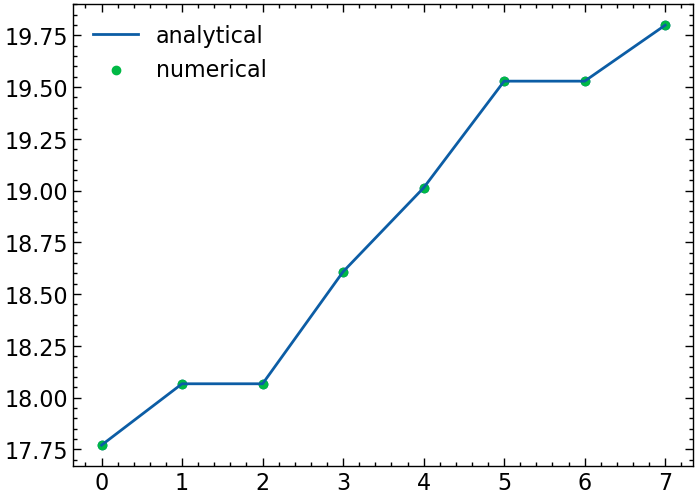

In [47]:
analytical = np.concatenate((analytical_energies_lower + E_gs, analytical_energies_upper + E_gs))
analytical_sorted = np.sort(analytical)
numerical_sorted = np.sort(eigenvalues[1:])  # skip ground state

plt.plot(analytical_sorted, label='analytical')
plt.scatter(np.arange(2*n), analytical_sorted)
plt.scatter(np.arange(2*n), numerical_sorted, label='numerical')
plt.legend()

In [74]:
n = 50
k_values = np.linspace(-np.pi, np.pi, 2, endpoint = False)
E_c = 1.0
E_j = 50.0
Ec1 = 1.1
Ec2_values = np.linspace(1.1, 10.0)
U = E_c / 2.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
capacitive_factor = np.sqrt(E_j * (E_c)**3)**(0.25)/np.sqrt(2)
gc1 = capacitive_factor / Ec1
gc2_values = capacitive_factor / Ec2_values
alpha_band = np.array([np.array([ssh_energies(0, omega_q, gc1, gc2, U, k) for k in k_values]) for gc2 in gc2_values])
beta_band = np.array([np.array([ssh_energies(1, omega_q, gc1, gc2, U, k) for k in k_values]) for gc2 in gc2_values])
alpha_beta = np.array([np.array([ssh_energies(1, omega_q, gc1, gc2, U, k) + ssh_energies(0, omega_q, gc1, gc2, U, k) for k in k_values]) for gc2 in gc2_values])
alpha_alpha = 2 * alpha_band
beta_beta = 2* beta_band

alpha_beta_inversed = (alpha_band + np.flip(beta_band, axis = 1))
alpha_alpha_inversed = (alpha_band + np.flip(alpha_band, axis = 1))
beta_beta_inversed = (beta_band + np.flip(beta_band, axis = 1))

In [75]:
alpha_band.shape

(50, 2)

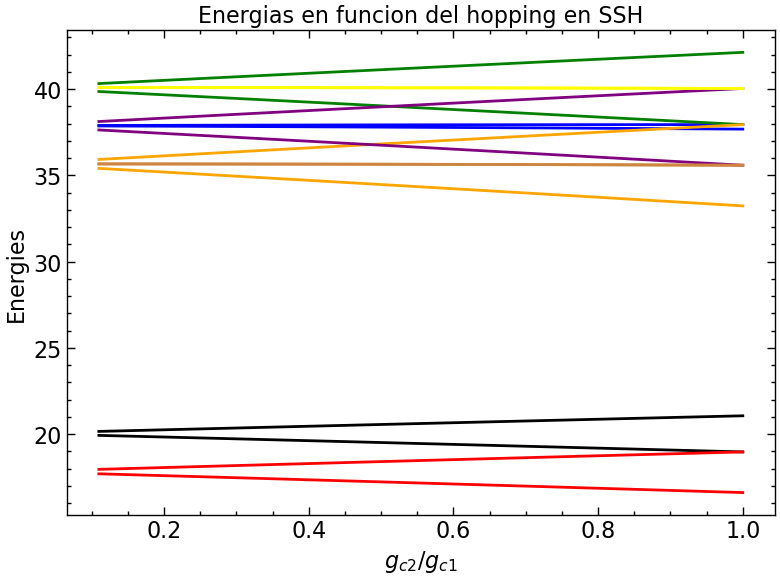

In [76]:
plt.plot(gc2_values/gc1, alpha_band, color = 'black', label = r'$\alpha$')
plt.plot(gc2_values/gc1, beta_band, color = 'red', label = r'$\beta$')
plt.plot(gc2_values/gc1, alpha_beta, color = 'blue', label = r'$\alpha\beta$')
plt.plot(gc2_values/gc1, alpha_alpha, color = 'green', label = r'$\alpha\alpha$')
plt.plot(gc2_values/gc1, beta_beta, color = 'orange', label = r'$\beta\beta$')
plt.plot(gc2_values/gc1, alpha_beta_inversed, color = 'purple', label = r'$\alpha\beta$ inverse')
plt.plot(gc2_values/gc1, alpha_alpha_inversed, color = 'yellow', label = r'$\alpha\alpha$ inverse')
plt.plot(gc2_values/gc1, beta_beta_inversed, color = 'peru', label = r'$\beta\beta$ inverse')

plt.xlabel(r'$g_{c2}/g_{c1}$')
plt.ylabel(r'Energies')
plt.title('Energias en funcion del hopping en SSH')
plt.tight_layout()

In [7]:
def squid_ssh(N, fock_transmon, E_c, E_J, EJ1, EJ2):
    omega_q = np.sqrt(8 * E_c * E_j) - E_c
    squid_factor = 2*np.sqrt(2 * E_c / E_J)
    gj1 = squid_factor * EJ1
    gj2 = squid_factor * EJ2
    
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    t_k     = [gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]
    delta_k = [gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_k():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon) + embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_k():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    diag_coeff = (gj1 + gj2)
    self_pairing_coeff = -(gj1 + gj2)/ 2.0
    H_diag = diag_coeff * np.sum(make_n_k())
    H_self_pairing = self_pairing_coeff * np.sum(make_self_pairing_k())
    H_hop = -np.sum(t_k * make_hopping_k())
    H_intersite_pairing = -np.sum(delta_k * make_intersite_pairing_k())

    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag()

In [ ]:
def phased_squid_ssh(N, fock_transmon, E_c, E_J, Ec1, Ec2, EJ1, EJ2):
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    squid_factor = 2*np.sqrt(2 * E_c / E_J)
    gj1 = squid_factor * EJ1
    gj2 = squid_factor * EJ2
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    capacitive_factor = np.sqrt(E_J * (E_c)**3)**(0.25)/np.sqrt(2)
    gc1 = capacitive_factor / Ec1
    gc2 = capacitive_factor / Ec2
    delta_ck = np.array([gc1 + np.exp(-1.0j * k) * gc2 for k in k_values])
    phase_correction = np.angle(delta_ck)
    
    
    delta_k = np.array([gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]) * np.exp(-1.0j * phase_correction)
    t_k     = np.array([gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]) * np.exp(-1.0j * phase_correction) 
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_k():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon) + embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_k():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon)
                        + embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    diag_coeff = (gj1 + gj2)
    self_pairing_coeff = -(gj1 + gj2)/ 2.0
    H_diag = diag_coeff * np.sum(make_n_k())
    H_self_pairing = self_pairing_coeff * np.sum(make_self_pairing_k())
    H_hop = -np.sum(t_k * make_hopping_k())
    H_intersite_pairing = -np.sum(delta_k * make_intersite_pairing_k())

    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag()

In [ ]:
def canonically_transformed_squid_ssh(N, fock_transmon, E_c, E_J, Ec1, Ec2, EJ1, EJ2):
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    squid_factor = 2*np.sqrt(2 * E_c / E_J)
    gj1 = squid_factor * EJ1
    gj2 = squid_factor * EJ2
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    capacitive_factor = np.sqrt(E_J * (E_c)**3)**(0.25)/np.sqrt(2)
    gc1 = capacitive_factor / Ec1
    gc2 = capacitive_factor / Ec2
    delta_ck = np.array([gc1 + np.exp(-1.0j * k) * gc2 for k in k_values])
    phase_correction = np.angle(delta_ck)
    
    
    delta_k = np.array([gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]) * np.exp(-1.0j * phase_correction)
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_kA():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_n_kB():
        ops = []
        for j in range(N):
            ops.append(embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_kA():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon))
                
        return np.array(ops)
    
    def make_self_pairing_kB():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    diag_coeff_A = (gj1 + gj2) - np.real(delta_k)
    diag_coeff_B = (gj1 + gj2) + np.real(delta_k)
    self_pairing_coeff_A = -0.5 * diag_coeff_B
    self_pairing_coeff_B = -0.5 * diag_coeff_A
    hopping_coeff = 1.0j * np.imag(delta_k)
    intersite_pairing_coeff = hopping_coeff
    
    H_diag = np.sum(diag_coeff_A * make_n_kA() + diag_coeff_B * make_n_kB())
    H_self_pairing = np.sum(self_pairing_coeff_A * make_self_pairing_kA() + self_pairing_coeff_B * make_self_pairing_kB())
    H_hop = np.sum(hopping_coeff * make_hopping_k())
    H_intersite_pairing = np.sum(intersite_pairing_coeff * make_intersite_pairing_k())

    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag()

In [64]:
def finally_transformed_squid_ssh(N, fock_transmon, E_c, E_J, Ec1, Ec2, EJ1, EJ2):
    omega_q = np.sqrt(8 * E_c * E_J) - E_c
    squid_factor = 2*np.sqrt(2 * E_c / E_J)
    gj1 = squid_factor * EJ1
    gj2 = squid_factor * EJ2
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    capacitive_factor = np.sqrt(E_J * (E_c)**3)**(0.25)/np.sqrt(2)
    gc1 = capacitive_factor / Ec1
    gc2 = capacitive_factor / Ec2
    delta_ck = np.array([gc1 + np.exp(-1.0j * k) * gc2 for k in k_values])
    phase_correction = np.angle(delta_ck)
    delta_k = np.array([gj1 + np.exp(-1.0j * k) * gj2 for k in k_values]) * np.exp(-1.0j * phase_correction)
    
    diag_coeff_A_0 = (gj1 + gj2) - np.real(delta_k)
    diag_coeff_B_0 = (gj1 + gj2) + np.real(delta_k)
    self_pairing_coeff_A_0 = -0.5 * diag_coeff_B_0
    self_pairing_coeff_B_0 = -0.5 * diag_coeff_A_0
    hopping_coeff_0 = 1.0j * np.imag(delta_k)
    intersite_pairing_coeff_0 = hopping_coeff_0
    
    Lambda_0 = E_c
    
    delta_ckA = Lambda_0 - np.abs(delta_ck)
    delta_ckB = Lambda_0 + np.abs(delta_ck)
    epsilon_ckA = omega_q + np.abs(delta_ck)
    epsilon_ckB = omega_q - np.abs(delta_ck)
    
    E_a = np.sqrt(epsilon_ckA**2 - delta_ckA**2)
    E_b = np.sqrt(epsilon_ckB**2 - delta_ckB**2)
    
    cosh_2ra = epsilon_ckA / E_a
    cosh_2rb = epsilon_ckB / E_b
    sinh_2ra = delta_ckA / E_a
    sinh_2rb = delta_ckB / E_b
    
    ra = 0.5 * np.asinh(sinh_2ra)
    rb = 0.5 * np.asinh(sinh_2rb)
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_kA():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_n_kB():
        ops = []
        for j in range(N):
            ops.append(embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_kA():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon))
                
        return np.array(ops)
    
    def make_self_pairing_kB():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    diag_coeff_A = diag_coeff_A_0 * cosh_2ra + 2.0 * self_pairing_coeff_A_0 * sinh_2ra
    diag_coeff_B = diag_coeff_B_0 * cosh_2rb + 2.0 * self_pairing_coeff_B_0 * sinh_2rb
    
    self_pairing_coeff_A =  self_pairing_coeff_A_0 * cosh_2ra + 0.5 * diag_coeff_A_0 * sinh_2ra
    self_pairing_coeff_B =  self_pairing_coeff_B_0 * cosh_2rb + 0.5 * diag_coeff_B_0 * sinh_2rb
    
    hopping_coeff = hopping_coeff_0 * np.exp(ra + rb)
    intersite_pairing_coeff = hopping_coeff
    
    ground_state_energy = 0.5 * np.sum(diag_coeff_A + diag_coeff_B - diag_coeff_A_0 - diag_coeff_B_0) 
    H_diag = np.sum(diag_coeff_A * make_n_kA() + diag_coeff_B * make_n_kB())
    H_self_pairing = np.sum(self_pairing_coeff_A * make_self_pairing_kA() + self_pairing_coeff_B * make_self_pairing_kB())
    H_hop = np.sum(hopping_coeff * make_hopping_k())
    H_intersite_pairing = np.sum(intersite_pairing_coeff * make_intersite_pairing_k())
    identity = qt.tensor([qt.qeye(fock_transmon)] * (2 * N))
    
    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag() + ground_state_energy * identity

In [10]:
def final_squid_ssh(N, fock_transmon, E_c, E_J, Ec1, Ec2, EJ1, EJ2):
    omega_q = np.sqrt(8 * E_c * E_j) - E_c
    squid_factor = 2*np.sqrt(2 * E_c / E_J)
    gj1 = squid_factor * EJ1
    gj2 = squid_factor * EJ2
    Lambda_0 = E_c
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    
    capacitive_factor = np.sqrt(E_J * (E_c)**3)**(0.25)/np.sqrt(2)
    gc1 = capacitive_factor / Ec1
    gc2 = capacitive_factor / Ec2
    delta_ck = np.array([gc1 + np.exp(-1.0j * k) * gc2 for k in k_values])
    phase_correction = np.angle(delta_ck)
    delta_jk = np.array([gj1 + gj2 * np.exp(-1.0j * k) for k in k_values]) * np.exp(-1.0j * phase_correction)
    
    delta_ckA = Lambda_0 - np.abs(delta_ck)
    delta_ckB = Lambda_0 + np.abs(delta_ck)
    epsilon_ckA = omega_q + np.abs(delta_ck)
    epsilon_ckB = omega_q - np.abs(delta_ck)
    
    E_a = np.sqrt(epsilon_ckA**2 - delta_ckA**2)
    E_b = np.sqrt(epsilon_ckB**2 - delta_ckB**2)
    
    cosh_2ra = epsilon_ckA / E_a
    cosh_2rb = epsilon_ckB / E_b
    sinh_2ra = delta_ckA / E_a
    sinh_2rb = delta_ckB / E_b
    
    cosh_ra = np.sqrt((1+cosh_2ra)/2.0)
    cosh_rb = np.sqrt((1+cosh_2rb)/2.0)
    sinh_ra = sinh_2ra / np.sqrt(2*(1+cosh_2ra))
    sinh_rb = sinh_2rb / np.sqrt(2*(1+cosh_2rb))
    
    aux_energy_A = (gj1 + gj2) - np.real(delta_jk)
    aux_energy_B = (gj1 + gj2) + np.real(delta_jk)
    aux_delta_A = aux_energy_B
    aux_delta_B = aux_energy_A
    
    diag_coeff_A = aux_energy_A * cosh_2ra - aux_delta_A * sinh_2ra
    diag_coeff_B = aux_energy_B * cosh_2rb - aux_delta_B * sinh_2rb
    self_pairing_coeff_A = aux_delta_A * cosh_2ra - aux_energy_A * sinh_2ra
    self_pairing_coeff_B = aux_delta_B * cosh_2rb - aux_energy_B * sinh_2rb
    t_k = 1.0j*np.imag(delta_jk) * (cosh_ra + sinh_ra) * (cosh_rb + sinh_rb)
    ground_state_energy = 0.5 * np.sum(diag_coeff_A + diag_coeff_B) - N * (gj1 + gj2)
    
    n_transmon = qt.num(fock_transmon)
    b_transmon    = qt.destroy(fock_transmon)
    bdag_transmon = b_transmon.dag()
    
    
    def make_n_kA():
        ops = []
        for j in range(N):
            ops.append(embed({2*j:   n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_n_kB():
        ops = []
        for j in range(N):
            ops.append(embed({2*j+1: n_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_self_pairing_kA():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j:   bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j:   bdag_transmon, 2*mj:   bdag_transmon}, 2*N, fock_transmon))
                
        return np.array(ops)
    
    def make_self_pairing_kB():
        ops = []
        for j in range(N):
            mj = (N - j) % N
            
            if mj == j:
                ops.append(embed({2*j+1: bdag_transmon * bdag_transmon}, 2*N, fock_transmon))
            else:
                ops.append(embed({2*j+1: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_hopping_k():
        ops  = []
        for j in range(N):
            ops.append(embed({2*j: bdag_transmon, 2*j+1: b_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    def make_intersite_pairing_k():
        ops  = []
        for j in range(N):
            mj = (N - j) % N
            ops.append(embed({2*j: bdag_transmon, 2*mj+1: bdag_transmon}, 2*N, fock_transmon))
        return np.array(ops)
    
    H_diag = np.sum(diag_coeff_A * make_n_kA() + diag_coeff_B * make_n_kB())
    H_self_pairing =  -0.5 * np.sum(self_pairing_coeff_A * make_self_pairing_kA() + self_pairing_coeff_B * make_self_pairing_kB())
    H_hop = np.sum(t_k * make_hopping_k())
    H_intersite_pairing = np.sum(t_k * make_intersite_pairing_k())
    identity = qt.tensor([qt.qeye(fock_transmon)] * (2 * N))
    return H_diag + H_self_pairing + H_self_pairing.dag() + H_hop + H_hop.dag() + H_intersite_pairing + H_intersite_pairing.dag() + ground_state_energy * identity

In [60]:
n = 2 # numero de celdas unidad
N = 20 # truncamiento del espacio de fock

E_c = 1.0
E_j = 50.0
Ec1 = 2.0
Ec2 = 3.0
EJ1 = 20.0
EJ2 = 10.0

H1 = squid_ssh(n, N, E_c, E_j, EJ1, EJ2)
H2 = phased_squid_ssh(n, N, E_c, E_j, Ec1, Ec2, EJ1, EJ2)
H3 = final_squid_ssh(n, N, E_c, E_j, Ec1, Ec2, EJ1, EJ2)
H4 = canonically_transformed_squid_ssh(n, N, E_c, E_j, Ec1, Ec2, EJ1, EJ2)

In [65]:
H5 = finally_transformed_squid_ssh(n, N, E_c, E_j, Ec1, Ec2, EJ1, EJ2)
H_csr5 = sp.csr_matrix(H5.data.as_scipy())
eigenvalues5, _ = eigsh(H_csr5, k=k_bands, which='SA')
eigenvalues5

array([-439.730659  , -432.83202379, -425.87425254, -419.01371507,
       -418.97561733])

In [66]:
H4 = canonically_transformed_squid_ssh(n, N, E_c, E_j, Ec1, Ec2, EJ1, EJ2)
H_csr4 = sp.csr_matrix(H4.data.as_scipy())
eigenvalues4, _ = eigsh(H_csr4, k=k_bands, which='SA')
eigenvalues4

array([-433.30537882, -426.72285425, -419.44897235, -412.86644778,
       -412.63124954])

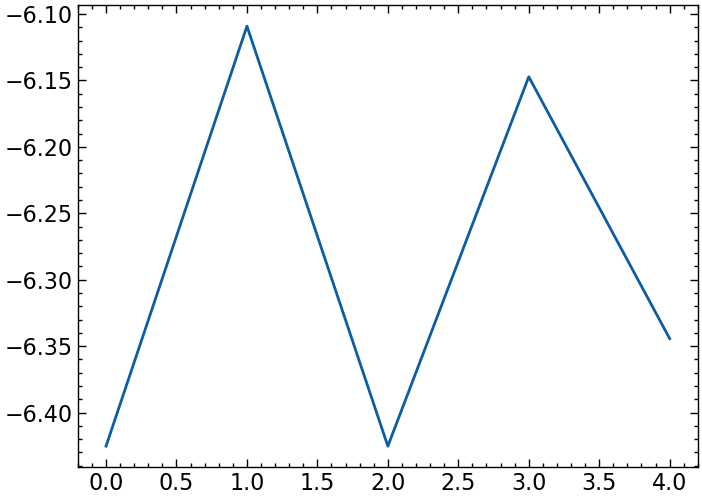

In [67]:
plt.plot(eigenvalues5-eigenvalues4)
# plt.plot(eigenvalues4)

In [36]:
H_csr1 = sp.csr_matrix(H1.data.as_scipy())
H_csr2 = sp.csr_matrix(H2.data.as_scipy())
H_csr3 = sp.csr_matrix(H3.data.as_scipy())
H_csr4 = sp.csr_matrix(H4.data.as_scipy())
k_bands = 2 * n+1

eigenvalues1, _ = eigsh(H_csr1, k=k_bands, which='SA')
eigenvalues2, _ = eigsh(H_csr2, k=k_bands, which='SA')
eigenvalues3, _ = eigsh(H_csr3, k=k_bands, which='SA')
eigenvalues4, _ = eigsh(H_csr4, k=k_bands, which='SA')


In [37]:
eigenvalues1

array([-3348.98227158, -3349.25298922, -3349.11879038, -3349.11647042,
       -3110.20850107])

In [38]:
eigenvalues2

array([-3349.25298922, -3348.98227158, -3349.11647042, -3349.11879038,
       -3110.20850107])

array([-1199.10569617, -1167.1023235 , -1139.776108  , -1125.96547198,
       -1111.10569617])

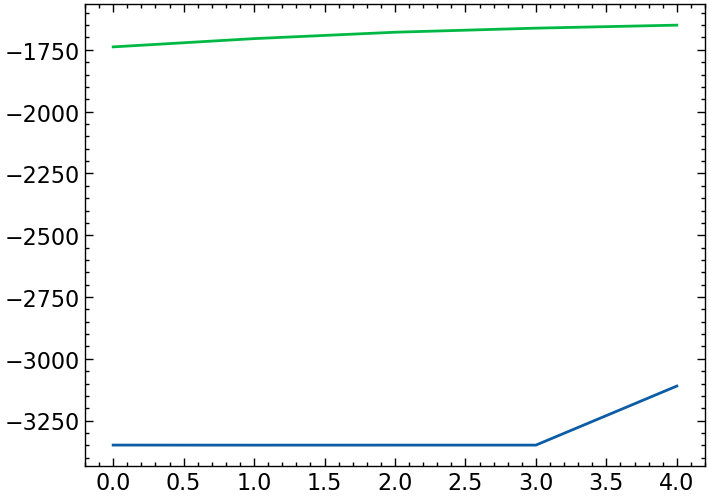

In [39]:
# truncamiento del espacio de fock
plt.plot(eigenvalues1)
plt.plot(eigenvalues4)

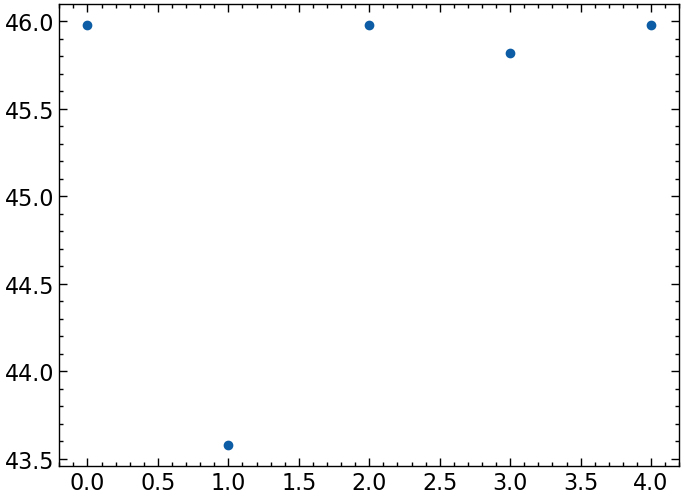

In [42]:
plt.scatter(np.arange(k_bands), eigenvalues4-eigenvalues3)

In [22]:
eigenvalues3

array([-509.20114847, -479.58996812, -449.87073556, -444.02624666,
       -421.20114835])

In [21]:
eigenvalues4

array([-493.19747141, -465.92765196, -433.86592242, -428.16710076,
       -406.59610297])

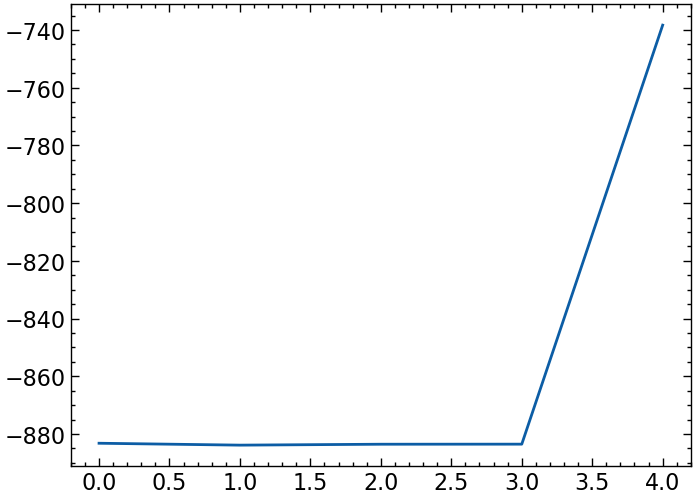

In [23]:
plt.plot(eigenvalues1)

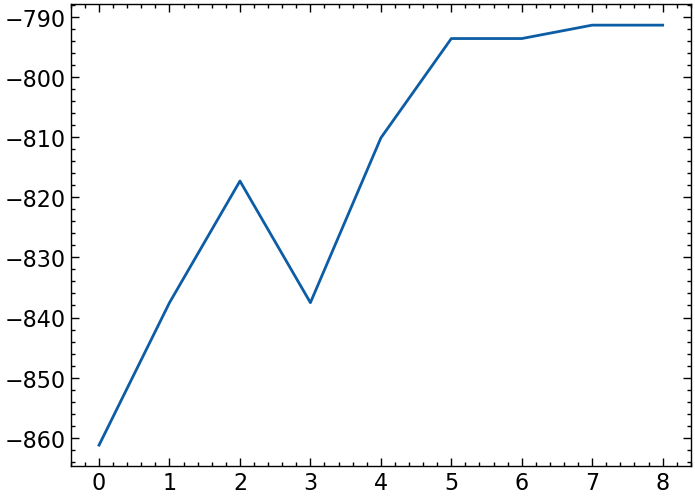

In [122]:
plt.plot(eigenvalues3)

In [78]:
gc1 = 3.0
gc2 = 4.0
gj1 = 30.0
gj2 = -40.0
E_J = 50.0
E_c = 1.0
k_values = np.linspace(-np.pi, np.pi, num = 50, endpoint= False)
omega_q = np.sqrt(8*E_c * E_J) - E_c
delta_ck = gc1 + gc2 * np.exp(-1.0j * k_values)
tk =  (gj1 * gc2 - gj2 * gc1) * np.sin(k_values) * np.pow((omega_q + E_c)**2/((omega_q-E_c)**2 - np.abs(delta_ck)**2), 0.25)/np.abs(delta_ck)

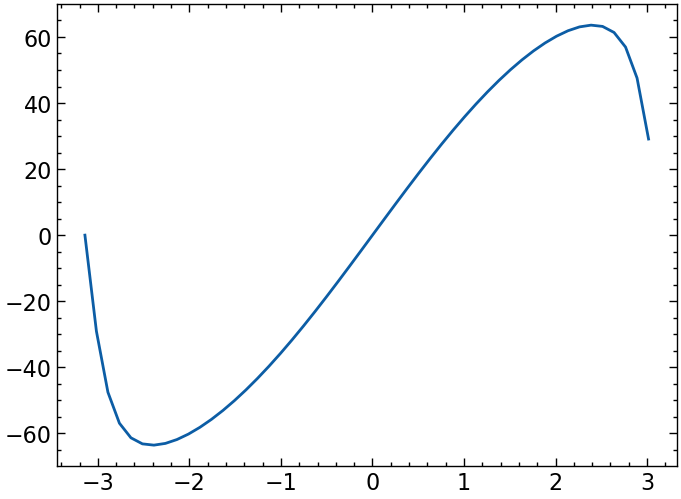

In [79]:
plt.plot(k_values, tk)